In [1]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.6 MB/s eta 0:00:00
  Using cached opencv_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached torch-2.13.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached torchvision-0.28.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached polars-1.42.1-py3-none-any.whl.metadata (10 kB)
  Using cached nvidia_ml_py-13.610.43-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.0.20-py3-none-any.whl.metadata (14 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached polars_runtime_32-1.42.1-cp310-abi3-manylinux_2_17_x86_6

In [2]:
import ultralytics
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
from pathlib import Path

print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.95


In [ ]:
# Ultralytics includes this sample image locally.
import ultralytics
sample_image = Path(ultralytics.__file__).parent / "assets" / "bus.jpg"
display(Image.open(sample_image))

In [6]:
# Load pretrained weights and run inference.
# On first run, yolo26n.pt is downloaded automatically.
try:
    model = YOLO("yolo26n.pt")
    results = model.predict(source=sample_image, conf=0.25, save=True, verbose=False)
    result = results[0]
    print(f"Found {len(result.boxes)} objects")
except (ConnectionError, OSError) as exc:
    model = None
    results = None
    result = None
    print("Model download was unavailable in this execution environment.")
    print("Re-run this cell in an internet-connected notebook; the remaining cells will then work.")
    print(type(exc).__name__ + ":", str(exc).splitlines()[-1])

Results saved to /home/jovyan/GIT/DataScienceWorkshop/ExampleProjects/runs/detect/predict
Found 5 objects


In [7]:
if result is not None:
    for box in result.boxes:
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())
        print(f"{result.names[class_id]:>10}: {confidence:.1%}")
else:
    print("No detections yet—re-run the preceding cell when model weights can be downloaded.")

       bus: 92.4%
    person: 91.3%
    person: 90.5%
    person: 87.0%
    person: 53.5%


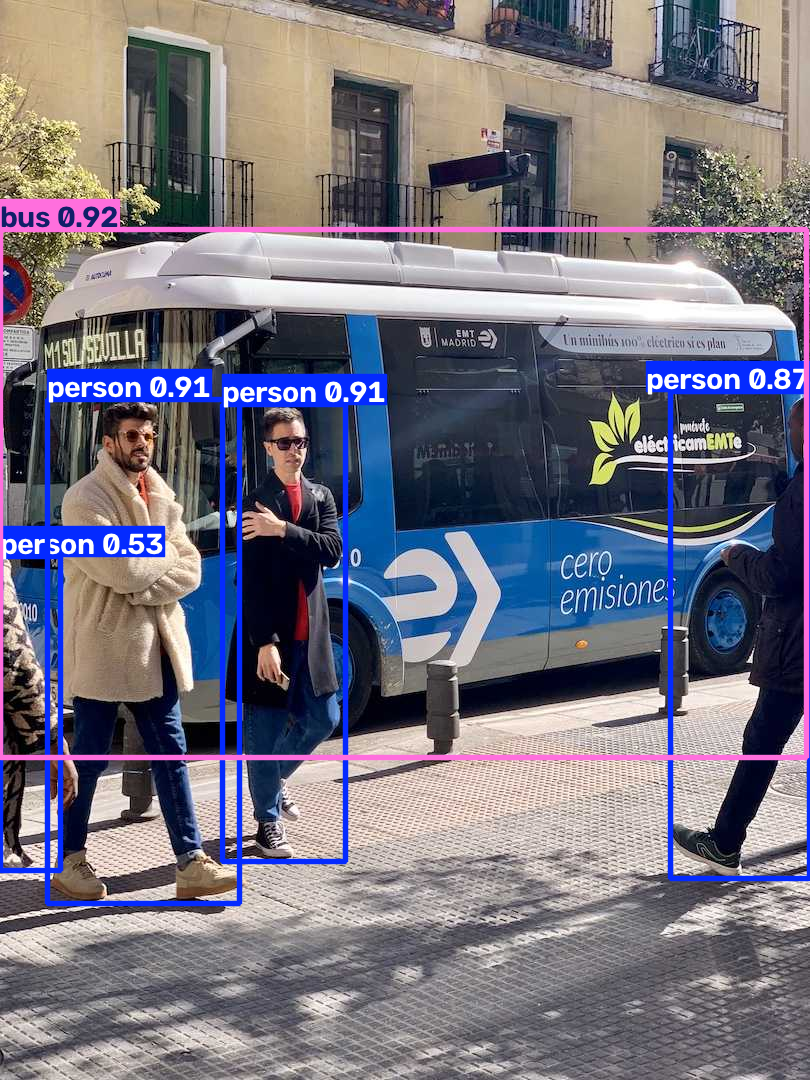

In [8]:
if result is not None:
    annotated_rgb = result.plot()[..., ::-1]  # BGR -> RGB
    display(Image.fromarray(annotated_rgb))
else:
    print("Annotated output will appear here after successful inference.")